In [68]:
import numpy as np 
import pandas as pd 

import datetime as dt
from datetime import datetime

import investpy as ipy
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 
import seaborn as sns
plt.style.use('ggplot')
%matplotlib inline

In [84]:
now = datetime.now()
today = now.strftime('%d/%m/%Y')

eth = ipy.get_crypto_historical_data(crypto='ethereum', from_date = '01/01/2020', to_date = today)
eth.head()

,Open,High,Low,Close,Volume,Currency
Date,,,,,,
2020-01-01,129.21,132.97,128.81,130.75,10353998,USD
2020-01-02,130.75,130.77,126.74,127.19,11446378,USD
2020-01-03,127.19,134.86,126.05,134.27,15674423,USD
2020-01-04,134.30,135.57,132.76,134.33,11160462,USD
2020-01-05,134.32,138.33,134.32,135.59,12192829,USD


In [85]:
eth_rets = np.log(1+eth['Close'].pct_change())
mu = eth_rets.mean()
sigma = eth_rets.std()
sim_rets = np.random.normal(mu, sigma, 365) #random value of normal distribution with mean and std as the parameters
                                 # impute int for days into the futre
eth_latest_price = eth['Close'].iloc[-1] # get last closing price
eth_simulation_365_days_from_now = eth_latest_price * (sim_rets + 1).cumprod() #get the cumulative returns

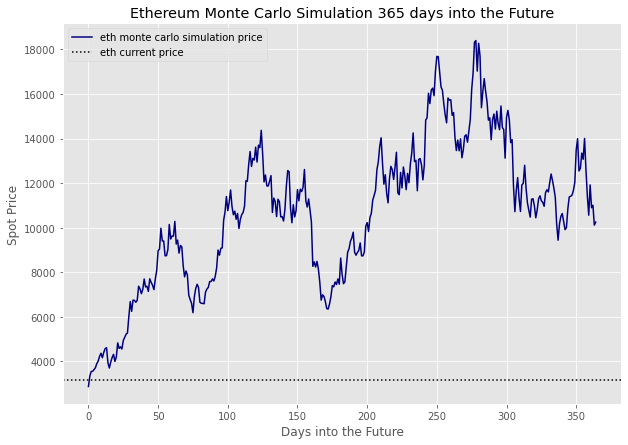

In [86]:
f, ax = plt.subplots(figsize=(10,7)) # one simulation

ax.plot(eth_simulation_365_days_from_now, color = 'navy', label = 'eth monte carlo simulation price')
ax.set_xlabel('Days into the Future')
ax.set_ylabel('Spot Price')
ax.set_title('Ethereum Monte Carlo Simulation 365 days into the Future')
plt.axhline(eth_latest_price, color='black', linestyle='dotted', label='eth current price')
ax.legend()

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles wi

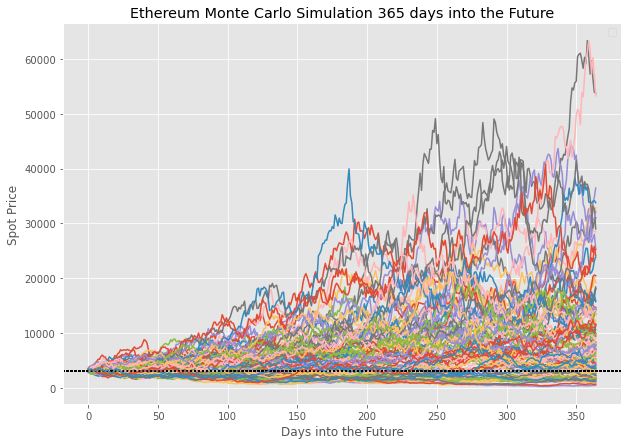

In [90]:
f, ax = plt.subplots(figsize=(10,7)) 

for i in range(100): #100 simulations 
    sim_rets = np.random.normal(mu, sigma, 365) 
    eth_simulation_365_days_from_now = eth_latest_price * (sim_rets + 1).cumprod()
    plt.axhline(eth_latest_price, color='black', linestyle='dotted')
    ax.plot(eth_simulation_365_days_from_now, 
    ax.set_xlabel('Days into the Future')
    ax.set_ylabel('Spot Price')
    ax.set_title('Ethereum Monte Carlo Simulation 365 days into the Future')
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.legend()
